In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

df = pd.read_csv(os.path.join('..', 'new_data.csv'), index_col=0)
df

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,
1,36,4.0,1,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,0,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,1,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,0,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
5,61,3.0,0,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3384,61,1.0,0,0.0,0.0,0,1,0,217.0,182.0,86.0,26.98,105.0,113.0,0
3385,60,1.0,0,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,46,1.0,0,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0


In [3]:
df['TenYearCHD'].value_counts(normalize=True)

TenYearCHD
0    0.848309
1    0.151691
Name: proportion, dtype: float64

### Handling Class Imbalance with SMOTE

The dataset has roughly 5.5 negative cases for every positive one. Training directly on this would likely produce a model that is biased toward predicting "no disease", and it would look accurate on paper but miss most of the actual at-risk patients, which is the worst possible failure mode in a healthcare setting.

We will use SMOTE (Synthetic Minority Oversampling Technique) to address this. SMOTE works by selecting a minority class sample, finding its k nearest neighbors in the same class, and generating synthetic points along the line segments connecting them.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape

(2341, 14)

In [5]:
from collections import Counter

Counter(y_train)

Counter({0: 1986, 1: 355})

In [6]:
from imblearn.over_sampling import SMOTE

over = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = over.fit_resample(X_train, y_train)

In [7]:
Counter(y_train_smote)

Counter({0: 1986, 1: 1986})

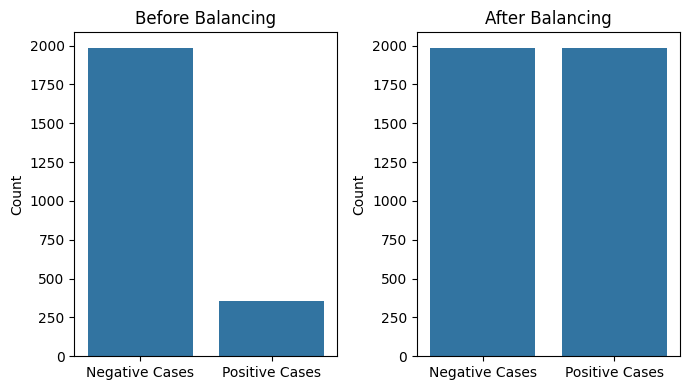

In [8]:
num_before = dict(Counter(y_train))
num_after = dict(Counter(y_train_smote))

labels = ['Negative Cases', 'Positive Cases']
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

sns.barplot(x=labels, y=list(num_before.values()), ax=axes[0])
axes[0].set_title('Before Balancing')
axes[0].set_ylabel('Count')

sns.barplot(x=labels, y=list(num_after.values()), ax=axes[1])
axes[1].set_title('After Balancing')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [9]:
Counter(y_test)

Counter({0: 497, 1: 89})

### Feature Scaling

In [10]:
X_train.dtypes.to_dict()

{'age': dtype('int64'),
 'education': dtype('float64'),
 'sex': dtype('int64'),
 'cigsPerDay': dtype('float64'),
 'BPMeds': dtype('float64'),
 'prevalentStroke': dtype('int64'),
 'prevalentHyp': dtype('int64'),
 'diabetes': dtype('int64'),
 'totChol': dtype('float64'),
 'sysBP': dtype('float64'),
 'diaBP': dtype('float64'),
 'BMI': dtype('float64'),
 'heartRate': dtype('float64'),
 'glucose': dtype('float64')}

In [11]:
from sklearn.preprocessing import StandardScaler

numerics = [
    'age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'
]

X_train_smote_scaled = X_train_smote.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_smote_scaled[numerics] = scaler.fit_transform(X_train_smote[numerics])
X_test_scaled[numerics] = scaler.transform(X_test[numerics])

In [12]:
pd.DataFrame(X_test_scaled, columns=X_test.columns).sample(10)

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
id,,,,,,,,,,,,,,
2600,-1.372409,2.0,1,-0.801539,0.0,0,0,0,-1.044682,-0.286154,0.361679,0.583674,1.743552,0.006718
46,0.442442,2.0,0,-0.801539,0.0,0,1,0,1.131774,1.139433,1.685333,-0.326789,1.215593,-0.170715
3258,-1.009439,1.0,0,-0.718911,0.0,0,0,0,-1.197034,-0.693464,-0.961975,-0.422628,0.335662,0.077691
1237,-1.251419,2.0,0,-0.801539,0.0,0,0,0,-0.130570,0.263716,0.439541,0.054041,-0.544269,-0.028769
3007,-1.856370,2.0,1,1.264168,0.0,0,0,0,-0.565862,-1.100775,-1.351285,-0.732841,-1.160221,0.006718
3069,-0.888449,1.0,1,-0.801539,0.0,0,1,1,-0.718214,1.546744,1.296023,0.485313,1.655559,3.874763
121,1.531353,4.0,1,-0.801539,0.0,0,0,0,0.696483,-0.571271,-0.845182,-0.934605,-0.104304,0.006718
3231,1.047393,3.0,0,-0.801539,0.0,0,1,0,0.957657,0.772854,1.218161,-0.753017,0.335662,0.042204
2126,1.894324,1.0,0,-0.801539,0.0,0,0,0,-0.391745,-1.060044,-0.884113,0.475225,1.215593,-0.738502


### Model Training and Evaluations

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm, columns=['Predicted: 0', 'Predicted: 1'], index=['Actual: 0', 'Actual: 1']
    )
    plt.figure(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def plot_roc(clf, X_test, y_test):
    probs = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    plt.figure(figsize=(8, 5))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (AUC = {round(auc, 3)})')
    plt.tight_layout()
    plt.show()
    return auc

### Logistic Regression

In [15]:
lr_params = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42), param_grid=lr_params, cv=5
)
lr_grid.fit(X_train_smote_scaled, y_train_smote)
print("Best params:", lr_grid.best_params_)

Best params: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


In [16]:
lr_pred = lr_grid.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, lr_pred)
logistic_f1 = f1_score(y_test, lr_pred)
print(f"Accuracy: {round(log_accuracy * 100, 2)}%")
print(f"F1 Score: {round(logistic_f1 * 100, 2)}%")
print()
print(classification_report(y_test, lr_pred))

Accuracy: 65.7%
F1 Score: 34.1%

              precision    recall  f1-score   support

           0       0.90      0.67      0.77       497
           1       0.24      0.58      0.34        89

    accuracy                           0.66       586
   macro avg       0.57      0.63      0.55       586
weighted avg       0.80      0.66      0.70       586



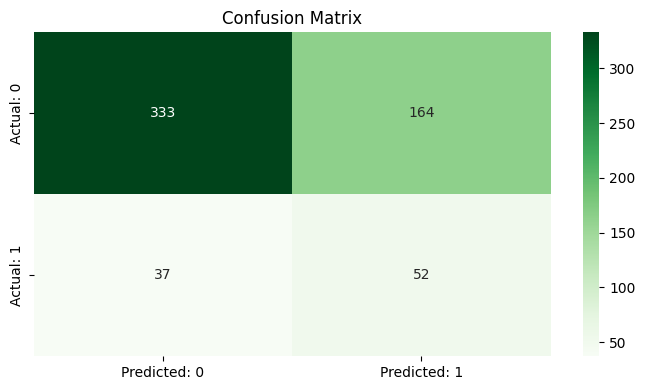

In [17]:
plot_confusion_matrix(y_pred=lr_pred, y_true=y_test)

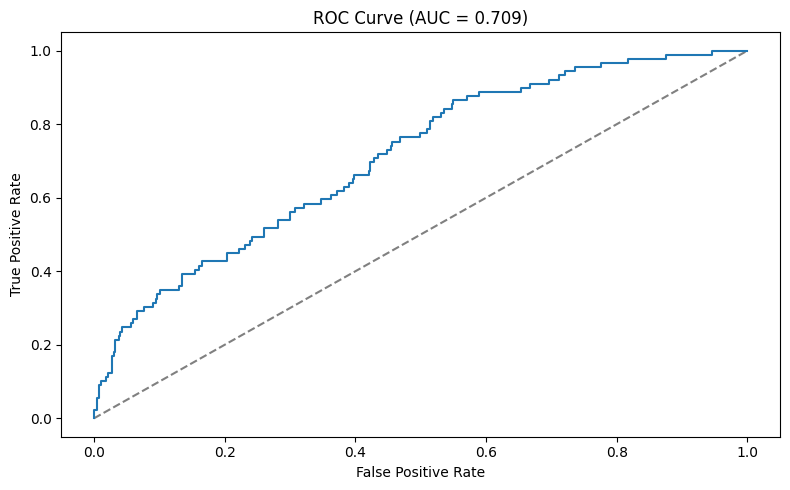

np.float64(0.708837293423462)

In [18]:
plot_roc(lr_grid, X_test_scaled, y_test)

In [19]:
# Let's try without SMOTE
lr_model = LogisticRegression(
    penalty='l2', C=0.01, class_weight='balanced', random_state=42
)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[numerics] = scaler.fit_transform(X_train[numerics])
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.01, class_weight='balanced', random_state=42)

In [20]:
lr_pred = lr_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, lr_pred)
logistic_f1 = f1_score(y_test, lr_pred)
print(f"Accuracy: {round(log_accuracy * 100, 2)}%")
print(f"F1 Score: {round(logistic_f1 * 100, 2)}%")
print()
print(classification_report(y_test, lr_pred))

Accuracy: 73.04%
F1 Score: 37.3%

              precision    recall  f1-score   support

           0       0.90      0.77      0.83       497
           1       0.29      0.53      0.37        89

    accuracy                           0.73       586
   macro avg       0.59      0.65      0.60       586
weighted avg       0.81      0.73      0.76       586



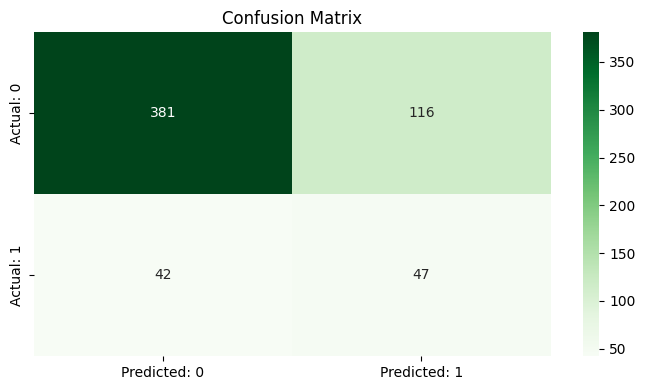

In [21]:
plot_confusion_matrix(y_pred=lr_pred, y_true=y_test)

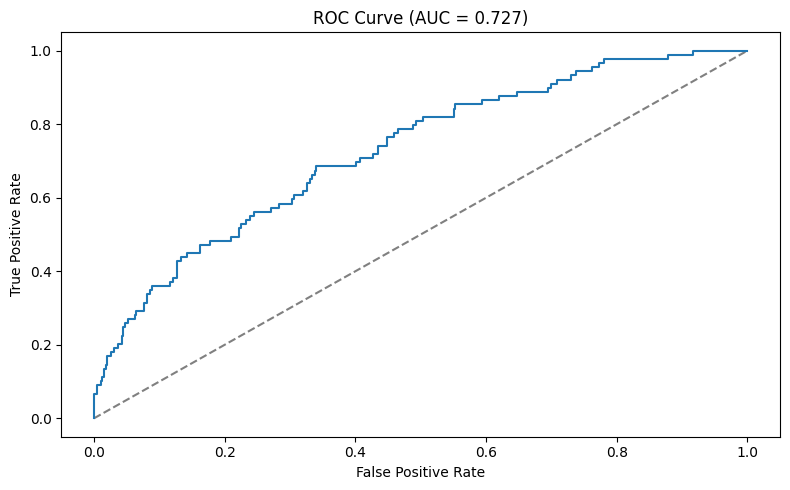

np.float64(0.7268555151131508)

In [22]:
plot_roc(lr_model, X_test_scaled, y_test)

As we can see LogisticRegression has a lot of False Positives.
NOTE: I used the SMOTE balanced and `class_weight='balanced` class imbalance handling.

### K-Nearest Neighbors

In [23]:
params= {'n_neighbors': np.arange(1, 16)}
knn_grid = GridSearchCV(KNeighborsClassifier(), scoring='accuracy', param_grid=params, cv=10)
knn_grid.fit(X_train_smote_scaled, y_train_smote)
print("Best params:", knn_grid.best_params_)

Best params: {'n_neighbors': np.int64(2)}


In [24]:
from sklearn.model_selection import cross_val_score

knn_f1_score = cross_val_score(
    estimator=KNeighborsClassifier(n_neighbors=2),
    X=X_train_smote_scaled,
    y=y_train_smote,
    cv=5,
    scoring='f1'
)

knn_f1_score.mean()

np.float64(0.8699709411223182)

In [25]:
knn_model = KNeighborsClassifier(n_neighbors=2)
knn_model.fit(X_train_smote_scaled, y_train_smote)
knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
print(f"Accuracy: {round(knn_accuracy * 100, 2)}%")
print(f"F1 Score: {round(knn_f1 * 100, 2)}%")
print()
print(classification_report(y_test, knn_pred))

Accuracy: 71.33%
F1 Score: 20.75%

              precision    recall  f1-score   support

           0       0.86      0.80      0.82       497
           1       0.18      0.25      0.21        89

    accuracy                           0.71       586
   macro avg       0.52      0.52      0.52       586
weighted avg       0.75      0.71      0.73       586



In [26]:
knn_model = KNeighborsClassifier(n_neighbors=2)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
print(f"Accuracy: {round(knn_accuracy * 100, 2)}%")
print(f"F1 Score: {round(knn_f1 * 100, 2)}%")
print()
print(classification_report(y_test, knn_pred))

Accuracy: 84.81%
F1 Score: 10.1%

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       497
           1       0.50      0.06      0.10        89

    accuracy                           0.85       586
   macro avg       0.68      0.52      0.51       586
weighted avg       0.80      0.85      0.79       586



### Decision Tree

In [27]:
tree_params = {
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': list(range(2, 15)),
    'min_samples_leaf': list(range(1, 10))
}

tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=tree_params, cv=5)
tree_grid.fit(X_train_smote_scaled, y_train_smote)
print("Best params:", tree_grid.best_params_)

Best params: {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6}


In [28]:
tree_pred = tree_grid.predict(X_test_scaled)

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)
print(f"Accuracy: {round(tree_accuracy * 100, 2)}%")
print(f"F1 Score: {round(tree_f1 * 100, 2)}%")
print()
print(classification_report(y_test, tree_pred))

Accuracy: 68.6%
F1 Score: 25.2%

              precision    recall  f1-score   support

           0       0.86      0.75      0.80       497
           1       0.20      0.35      0.25        89

    accuracy                           0.69       586
   macro avg       0.53      0.55      0.53       586
weighted avg       0.76      0.69      0.72       586



In [30]:
tree_params = {
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': list(range(2, 15)),
    'min_samples_leaf': list(range(1, 10))
}

tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'), param_grid=tree_params, cv=5)
tree_grid.fit(X_train_scaled, y_train)
print("Best params:", tree_grid.best_params_)

tree_pred = tree_grid.predict(X_test_scaled)

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)
print(f"Accuracy: {round(tree_accuracy * 100, 2)}%")
print(f"F1 Score: {round(tree_f1 * 100, 2)}%")
print()
print(classification_report(y_test, tree_pred))

Best params: {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 80.2%
F1 Score: 22.67%

              precision    recall  f1-score   support

           0       0.86      0.91      0.89       497
           1       0.28      0.19      0.23        89

    accuracy                           0.80       586
   macro avg       0.57      0.55      0.56       586
weighted avg       0.77      0.80      0.79       586

